## Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
# import matplotlib.animation
# import mpl_toolkits.mplot3d.art3d as art3d

In [4]:
import scipy, scipy.interpolate

In [5]:
# import sqlite3

In [6]:
import itertools

In [7]:
# from ipywidgets import interact
# import ipywidgets as widgets

In [8]:
# import IPython.display

In [9]:
# %matplotlib inline

## Basic 1d Path

### Definition

In [10]:
f = lambda t: (t - 1)**3
t = np.linspace(0, 2, 200)

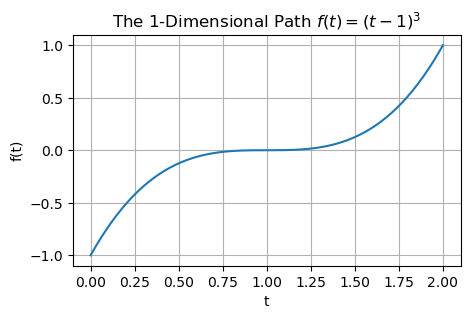

In [17]:
plt.figure(figsize=(5, 3))
plt.plot(t, f(t))
plt.xlabel('t')
plt.ylabel('f(t)')
plt.title('The 1-Dimensional Path $f(t) = (t-1)^3$')
plt.grid()
plt.show()

### Interpolation

In [18]:
f = lambda t: (t - 1)**3
t = np.linspace(0, 2, 2000)
t_samples = np.linspace(0, 2, 8)

In [19]:
interpolation_methods = (('linear', 'Linear Interpolation'),
                         ('previous', 'Previous Point Interpolation'),
                         ('next', 'Next Point Interpolation'),
                         ('quadratic', 'Quadratic Interpolation'))

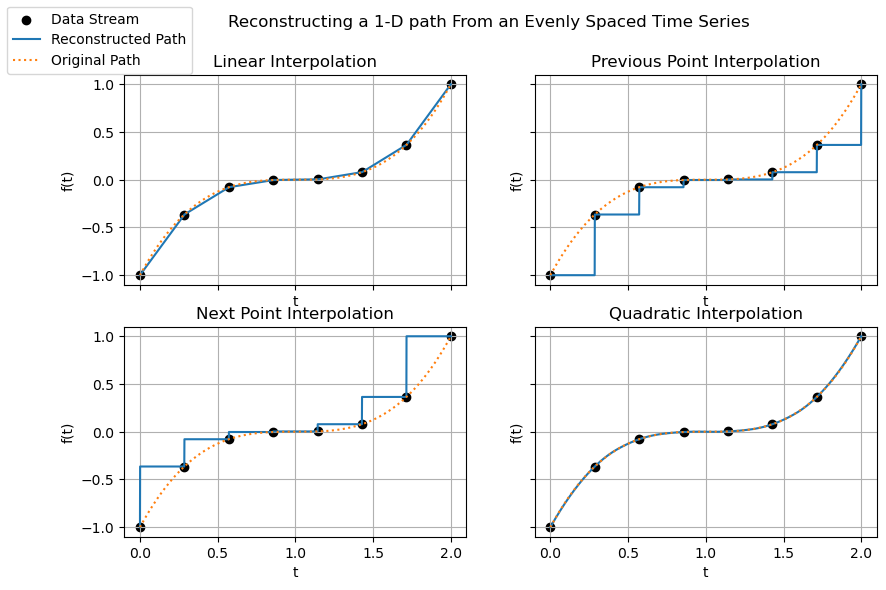

In [25]:
# figure_height = 8.5
figure_height = 6
fig, ax = plt.subplots(2, 2, figsize=(figure_height * scipy.constants.golden_ratio, figure_height),
                     sharex=True, sharey=True)
for method, ax in zip(interpolation_methods, ax.flatten()):
    f_interpolated = scipy.interpolate.interp1d(t_samples, f(t_samples), kind=method[0])

    p_time_series = ax.scatter(t_samples, f(t_samples), color='k')
    p_reconstructed, = ax.plot(t, f_interpolated(t))
    p_original, = ax.plot(t, f(t), linestyle=':')
    ax.set_xlabel('t')
    ax.set_ylabel('f(t)')
    ax.set_title('{}'.format(method[1]))
    ax.grid()
fig.legend([p_time_series, p_reconstructed, p_original],
           ['Data Stream', 'Reconstructed Path', 'Original Path'], loc=2)
plt.suptitle('Reconstructing a 1-D path From an Evenly Spaced Time Series')
plt.show()

In [60]:
f = lambda t: (t - 1)**3
t = np.linspace(0, 2, 2000)

In [27]:
np.random.seed(3)
t_samples = np.random.uniform(0, 2, size=8)
t_samples = np.insert(t_samples, [0, -1], [t[0], t[-1]])
reconstuctable_samples_mask = (t > min(t_samples)) & (t < max(t_samples))

In [28]:
interpolation_method = ('linear', 'Linear Interpolation')
f_interpolated = scipy.interpolate.interp1d(t_samples, f(t_samples), kind=interpolation_method[0])

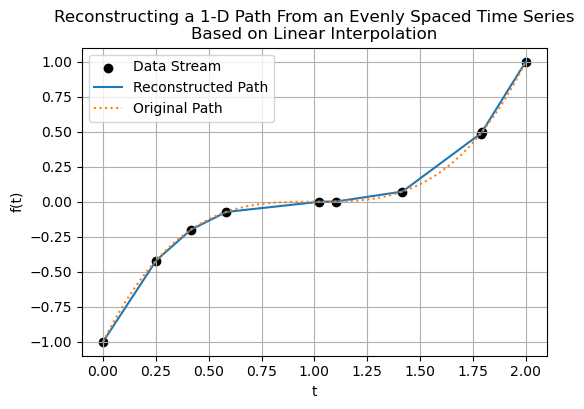

In [30]:
plt.figure(figsize=(6, 4))
p_time_series = plt.scatter(t_samples, f(t_samples), color='k')
p_reconstructed, = plt.plot(t[reconstuctable_samples_mask], f_interpolated(t[reconstuctable_samples_mask]))
p_original, = plt.plot(t, f(t), linestyle=':')

plt.xlabel('t')
plt.ylabel('f(t)')
plt.title('{}'.format(method[1]))
plt.legend([p_time_series, p_reconstructed, p_original], ['Data Stream', 'Reconstructed Path', 'Original Path'])
plt.title('Reconstructing a 1-D Path From an Evenly Spaced Time Series\nBased on Linear Interpolation')
plt.grid()
plt.show()

## Computing Signatures

In [91]:
def compute_path_signature(X, a=0, b=1, steps=10**4, level_threshold=4):
    N = len(X)
    t = np.linspace(a, b, steps)
    dt = t[1] - t[0]
    X_t = [Xi(t) for Xi in X]
    t = t[:-1]
    dX_t = [np.diff(Xi_t) for Xi_t in X_t]
    X_prime_t = [dXi_t / dt for dXi_t in dX_t]
    
    signature = [[np.ones(len(t))]]
    for k in range(level_threshold):
        previous_level = signature[-1]
        current_level = []
        for previous_level_integral in previous_level:
            for i in range(N):
                current_level.append(np.cumsum(previous_level_integral * dX_t[i]))
        signature.append(current_level)

    signature_terms = [list(itertools.product(*([np.arange(1, N+1).tolist()] * i)))
                       for i in range(0, level_threshold+1)]
    
    return t, X_t, X_prime_t, signature, signature_terms

In [66]:
paths = ((lambda t: t, '$W_t = t$'),
         (lambda t: 2 * t, '$X_t = 2t$'),
         (lambda t: np.sin(np.pi / 2 * t) + 1, '$Y_t = sin(\\frac{\\pi}{2} t) + 1$'),
         (lambda t: np.where(t < 0.5, -1 * t, 3 * t - 2), '$Z_t = -t $ if $ t < 0.5; 3 * t - 2$ otherwise'))

In [103]:
paths2 = ((lambda t: (-1) ** (t), '$W_t = (-1) ** (t)$'),
         (lambda t: (-1) ** (t + 1), '$X_t = (-1) ** (t + 1)$'))

In [75]:
# ts, X_t, X_prime_t, signature, signature_terms = compute_path_signature([paths[2][0]], steps=10)

In [78]:
np.linspace(0, 9, 10)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [92]:
ts, X_t, X_prime_t, signature, signature_terms = compute_path_signature([paths2[0][0]], a=0, b=9, steps=10)

In [93]:
ts

array([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [94]:
X_t

[array([ 1., -1.,  1., -1.,  1., -1.,  1., -1.,  1., -1.])]

In [95]:
X_prime_t

[array([-2.,  2., -2.,  2., -2.,  2., -2.,  2., -2.])]

In [96]:
signature

[[array([1., 1., 1., 1., 1., 1., 1., 1., 1.])],
 [array([-2.,  0., -2.,  0., -2.,  0., -2.,  0., -2.])],
 [array([ 4.,  4.,  8.,  8., 12., 12., 16., 16., 20.])],
 [array([ -8.,   0., -16.,   0., -24.,   0., -32.,   0., -40.])],
 [array([ 16.,  16.,  48.,  48.,  96.,  96., 160., 160., 240.])]]

In [102]:
signature_terms

[[()], [(1,)], [(1, 1)], [(1, 1, 1)], [(1, 1, 1, 1)]]

In [97]:
ts, X_t, X_prime_t, signature, signature_terms = compute_path_signature([paths2[1][0]], a=0, b=9, steps=10)

In [98]:
ts

array([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [99]:
X_t

[array([-1.,  1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.])]

In [100]:
X_prime_t

[array([ 2., -2.,  2., -2.,  2., -2.,  2., -2.,  2.])]

In [101]:
signature

[[array([1., 1., 1., 1., 1., 1., 1., 1., 1.])],
 [array([2., 0., 2., 0., 2., 0., 2., 0., 2.])],
 [array([ 4.,  4.,  8.,  8., 12., 12., 16., 16., 20.])],
 [array([ 8.,  0., 16.,  0., 24.,  0., 32.,  0., 40.])],
 [array([ 16.,  16.,  48.,  48.,  96.,  96., 160., 160., 240.])]]

In [102]:
signature_terms

[[()], [(1,)], [(1, 1)], [(1, 1, 1)], [(1, 1, 1, 1)]]

In [104]:
paths3 = ((lambda t: (t) ** (10), '$W_t = (t) ** (10)$'),
         (lambda t: (t) ** (1 / 10), '$X_t = (t) ** (1 / 10)$'))

In [105]:
ts, X_t, X_prime_t, signature, signature_terms = compute_path_signature([paths3[0][0]], a=0, b=1, steps=20)

In [106]:
ts

array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842])

In [107]:
X_t

[array([0.00000000e+00, 1.63103767e-13, 1.67018257e-10, 9.63111431e-09,
        1.71026695e-07, 1.59281022e-06, 9.86226106e-06, 4.60727771e-05,
        1.75131336e-04, 5.68707669e-04, 1.63103767e-03, 4.23049165e-03,
        1.00989553e-02, 2.24852393e-02, 4.71785237e-02, 9.40538507e-02,
        1.79334488e-01, 3.28816199e-01, 5.82356653e-01, 1.00000000e+00])]

In [108]:
X_prime_t

[array([3.09897157e-12, 3.17024791e-09, 1.79817825e-07, 3.06651604e-06,
        2.70138870e-05, 1.57119566e-04, 6.87999805e-04, 2.45211262e-03,
        7.47795033e-03, 2.01842699e-02, 4.93896257e-02, 1.11500810e-01,
        2.35339395e-01, 4.69172405e-01, 8.90631213e-01, 1.62033211e+00,
        2.84015250e+00, 4.81726864e+00, 7.93522359e+00])]

In [109]:
signature

[[array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.])],
 [array([1.63103767e-13, 1.67018257e-10, 9.63111431e-09, 1.71026695e-07,
         1.59281022e-06, 9.86226106e-06, 4.60727771e-05, 1.75131336e-04,
         5.68707669e-04, 1.63103767e-03, 4.23049165e-03, 1.00989553e-02,
         2.24852393e-02, 4.71785237e-02, 9.40538507e-02, 1.79334488e-01,
         3.28816199e-01, 5.82356653e-01, 1.00000000e+00])],
 [array([2.66028387e-26, 2.78678835e-20, 9.11776589e-17, 2.76941305e-14,
         2.29232546e-12, 8.38478084e-11, 1.75216684e-09, 2.43543646e-08,
         2.48184244e-07, 1.98088448e-06, 1.29778528e-05, 7.22432053e-05,
         3.50751764e-04, 1.51574447e-03, 5.92454948e-03, 2.12183089e-02,
         7.03703168e-02, 2.18021287e-01, 6.35664634e-01])],
 [array([4.33902319e-39, 4.64989997e-30, 8.62918772e-25, 4.47057319e-21,
         3.26366115e-18, 6.96638991e-16, 6.41435045e-14, 3.20728271e-12,
         1.00886727e-10, 2.20523973e-09, 3.59405710e-

In [110]:
signature_terms

[[()], [(1,)], [(1, 1)], [(1, 1, 1)], [(1, 1, 1, 1)]]

In [ ]:
def plot_path_signature(t, X_t, X_prime_t, signature, signature_terms, path_title):
    path_symbol = path_title[1]
    
    # Flatten lists
    signature = [integral for level in signature for integral in level] 
    signature_terms = [term for level in signature_terms for term in level]
    
    for i, ax in enumerate(axs):
        n = i + 1
        signature_filtered, signature_terms_filtered = zip(*[(integral, term)
                                                             for integral, term in zip(signature, signature_terms)
                                                             if len(term) > 0 and term[-1] == n])
        for integral, term in zip(signature_filtered, signature_terms_filtered):
            ax.plot(t, integral, label='$S(' + path_symbol + ')_{a,t}^{' +','.join([str(v) for v in term]) + '}$')
        
        ax.plot(t, X_prime_t[i], color='black', linestyle=':', label="$" + path_symbol + "'_t$" if len(axs) == 1 else "$" + path_symbol + "'_t^{}$".format(n))
        
        if len(axs) == 1:
            ylabel = '$S(' + path_symbol + ')_{a,t}^{i_1, \ldots, i_k}$'
            title = path_title
        else:
            ylabel = '$S(' + path_symbol + ')_{a,t}^{i_1, \ldots, i_{k-1}, nnn}$'.replace('nnn', str(n))
            title = 'Signature terms ' + ylabel
        
        ax.set_title(title, fontsize=16)
        ax.set_xlabel('t', fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
    
        ax.grid()
        ax.legend(fontsize=14)
        

ValueError: x and y must have same first dimension, but have shapes (2000,) and (19,)

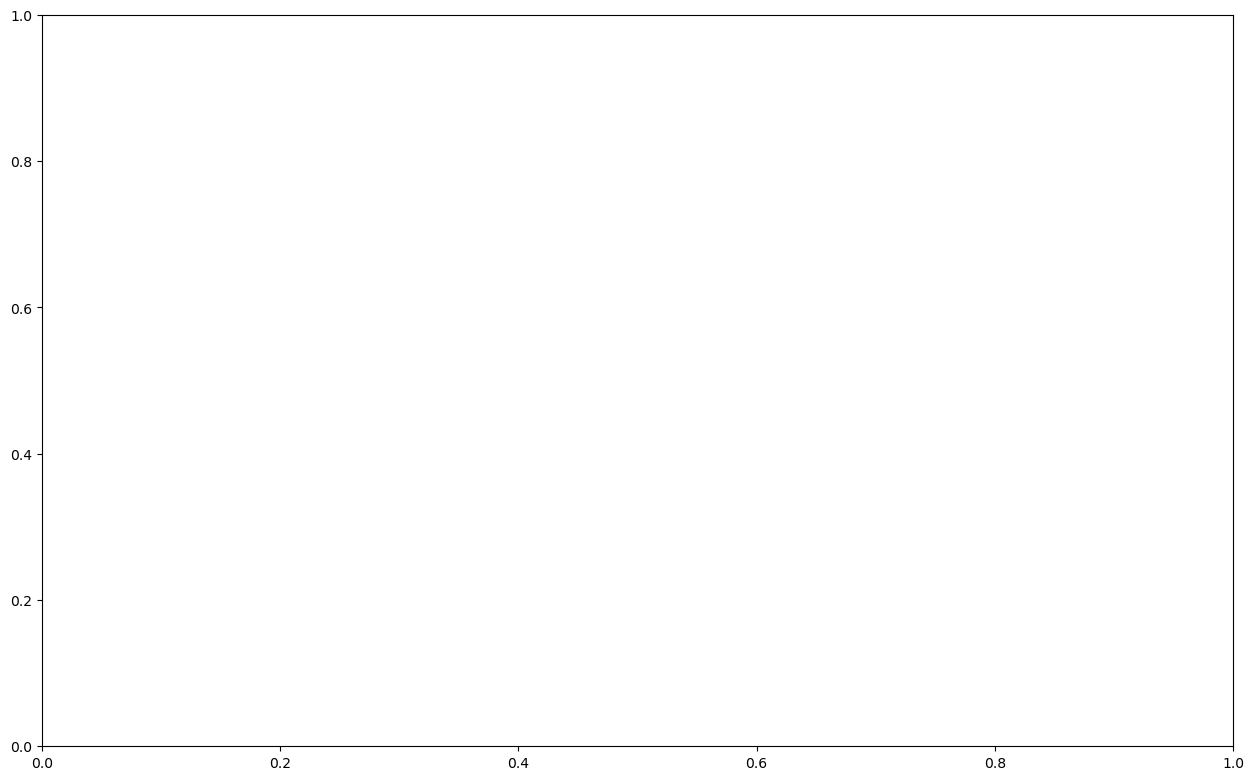

In [113]:
figure_height = 9.5
plt.figure(figsize=(9,6))
plot_path_signature(t, X_t, X_prime_t, signature, signature_terms, path[1], [axs])

In [ ]:
def plot_path_signature(t, X_t, X_prime_t, signature, signature_terms, path_title, axs):
    path_symbol = path_title[1]
    
    # Flatten lists
    signature = [integral for level in signature for integral in level] 
    signature_terms = [term for level in signature_terms for term in level]
    
    for i, ax in enumerate(axs):
        n = i + 1
        signature_filtered, signature_terms_filtered = zip(*[(integral, term)
                                                             for integral, term in zip(signature, signature_terms)
                                                             if len(term) > 0 and term[-1] == n])
        for integral, term in zip(signature_filtered, signature_terms_filtered):
            ax.plot(t, integral, label='$S(' + path_symbol + ')_{a,t}^{' +','.join([str(v) for v in term]) + '}$')
        
        ax.plot(t, X_prime_t[i], color='black', linestyle=':', label="$" + path_symbol + "'_t$" if len(axs) == 1 else "$" + path_symbol + "'_t^{}$".format(n))
        
        if len(axs) == 1:
            ylabel = '$S(' + path_symbol + ')_{a,t}^{i_1, \ldots, i_k}$'
            title = path_title
        else:
            ylabel = '$S(' + path_symbol + ')_{a,t}^{i_1, \ldots, i_{k-1}, nnn}$'.replace('nnn', str(n))
            title = 'Signature terms ' + ylabel
        
        ax.set_title(title, fontsize=16)
        ax.set_xlabel('t', fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
    
        ax.grid()
        ax.legend(fontsize=14)
        

In [ ]:
figure_height = 9.5
fig, axs = plt.subplots(2, 2, figsize=(figure_height * scipy.constants.golden_ratio, figure_height),
                        sharex=True, sharey=True)

for path, ax in zip(paths, axs.flatten()):
    t, X_t, X_prime_t, signature, signature_terms = compute_path_signature([path[0]])
    plot_path_signature(t, X_t, X_prime_t, signature, signature_terms, path[1], [ax])

plt.suptitle('Examples of Signatures of 1-Dimensional Paths', fontsize=16)
plt.show()

## Basic 2d Path

In [10]:
# Read data corresponding to a single glyph entry, for a given user
conn = sqlite3.connect('data/corr_numeral_gesture_dataset/database.sqlite')
df = pd.read_sql_query("SELECT zglyph.zindex, zglyph.zsubject, zglyph.zcharacter, zglyph.zduration, "
                       "ztouch.ztimestamp, ztouch.zx, ztouch.zy "
                       "FROM zglyph, zstroke, ztouch "
                       "WHERE zstroke.zglyph=zglyph.z_pk AND ztouch.zstroke=zstroke.z_pk "
                       "AND zglyph.zsubject=1 AND zglyph.zcharacter=2;", conn)

df = df[df['ZINDEX'] == df['ZINDEX'].unique()[2]]
df = df[['ZTIMESTAMP', 'ZX', 'ZY']].set_index('ZTIMESTAMP', drop=True).sort_index()

# Process the data for playback
PLAYBACK_SPEED = 0.33
df.index = df.index / PLAYBACK_SPEED
FRAME_RATE=40
t = np.arange(df.index.min(), df.index.max(), 1/FRAME_RATE)
df = df.reindex(df.index.union(t)).interpolate().loc[t]

# Set up the plot
fig, ax = plt.subplots()
ax.set_xlim(0, 300)
ax.set_ylim(400, 0)
ax.set_xlabel('x(t)')
ax.set_ylabel('y(t)')
ax.set_title('The 2-Dimensional Path $\mathbf{g}(t) = (x(t), y(t))$\n'
             'for a person drawing the digit "2" on a touchscreen')
ax.grid()
line_plot, = ax.plot([],[], alpha=0.15)
scatter_plot = ax.scatter([], [], color='k')
text_box = ax.text(250, 50, '', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Animate the plot
def animate(i):
    selected_data = df.iloc[:int(i+1)]
    line_plot.set_data(selected_data['ZX'], selected_data['ZY'])
    scatter_plot.set_offsets(selected_data[['ZX', 'ZY']].iloc[i])
    text_box.set_text('t={:.1f}s'.format(df.index[i]))
anim = matplotlib.animation.FuncAnimation(fig, animate, len(df), interval=1000/FRAME_RATE)

plt.close(fig)
IPython.display.HTML(anim.to_jshtml())

In [13]:
def plot_Y_against_X(a, b, X, Y, xlim, ylim, title):
    t = np.linspace(a, b, 200)
    X_t = X(t)
    Y_t = Y(t)
    dX_t = np.diff(X(t))
    dX_t = np.append(dX_t, dX_t[-1])
    
    plt.plot(X_t, Y_t, color='black')
    plt.fill_between(X_t, Y_t, where=~(Y_t >= 0) ^ (dX_t >= 0), facecolor='green', interpolate=True)
    plt.fill_between(X_t, Y_t, where=(Y_t >= 0) ^ (dX_t >= 0), facecolor='red', interpolate=True)
    
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.xlabel('$X_t$')
    plt.ylabel('$Y_t$')
    plt.title(title)
    plt.grid()
    plt.gca().set_aspect('equal', adjustable='box')

Slider = lambda value: widgets.SelectionSlider(options=[("{:.4}".format(i), i)
                                                        for i in sorted(np.append(np.linspace(0, np.pi*2), value))],
                                               continuous_update=False, value=value)

interact(lambda a, b: plot_Y_against_X(a, b,
                                       X=lambda t: t, Y=lambda t: np.cos(t),
                                       xlim=(0, np.pi*2), ylim=(-1.1, 1.1),
                                       title='Geometric interpretation of the path integral $\int_{a}^{b} Y_t \, dX_t$\n'
                                             'for $Y_t=cos(t)$, $X_t=t$ '
                                             'based on plotting $Y_t$ against $X_t$'),
         a=Slider(value=0),
         b=Slider(value=np.pi/2));

interactive(children=(SelectionSlider(continuous_update=False, description='a', options=(('0.0', 0.0), ('0.0',…

In [14]:
interact(lambda a, b: plot_Y_against_X(a, b,
                                       X=lambda t: np.sin(t), Y=lambda t: np.cos(t),
                                       xlim=(-1.1, 1.1), ylim=(-1.1, 1.1),
                                       title='Geometric interpretation of the path integral $\int_{a}^{b} Y_t \, dX_t$\n'
                                             'for $Y_t=cos(t)$, $X_t=sin(t)$ '
                                             'based on plotting $Y_t$ against $X_t$'),
         a=Slider(value=0),
         b=Slider(value=np.pi/2));

interactive(children=(SelectionSlider(continuous_update=False, description='a', options=(('0.0', 0.0), ('0.0',…

In [15]:
def plot_X_against_t(a, b, X, tlim, xlim, title):
    t = np.linspace(a, b, 200)
    X_t = X(t)
    
    plt.plot(t, X_t)
    plt.scatter([a, b], [X(a), X(b)], color='k')
    plt.hlines([X(a), X(b)], tlim[0], tlim[1], linestyle=':', color='gray')
    plt.vlines(tlim[1] - 0.25, X(a), X(b), linewidth=3, color=('green' if X(b) >= X(a) else 'red'))
    
    plt.xlim(*tlim)
    plt.ylim(*xlim)
    plt.xlabel('$t$')
    plt.ylabel('$X_t$')
    plt.title(title)
    plt.grid()
    plt.gca().set_aspect('equal', adjustable='box')

interact(lambda a, b: plot_X_against_t(a, b,
                                       X=lambda t: np.sin(t),
                                       tlim=(0, np.pi*2 + 0.5),
                                       xlim=(-1.1, 1.1),
                                       title='Geometric interpretation of the path integral $\int_{a}^{b} Y_t \, dX_t$\n'
                                             'for $X_t=sin(t)$, $Y_t=1$ '
                                             'based on plotting $X_t$ against $t$'),
         a=Slider(value=0),
         b=Slider(value=np.pi/2));

interactive(children=(SelectionSlider(continuous_update=False, description='a', options=(('0.0', 0.0), ('0.0',…

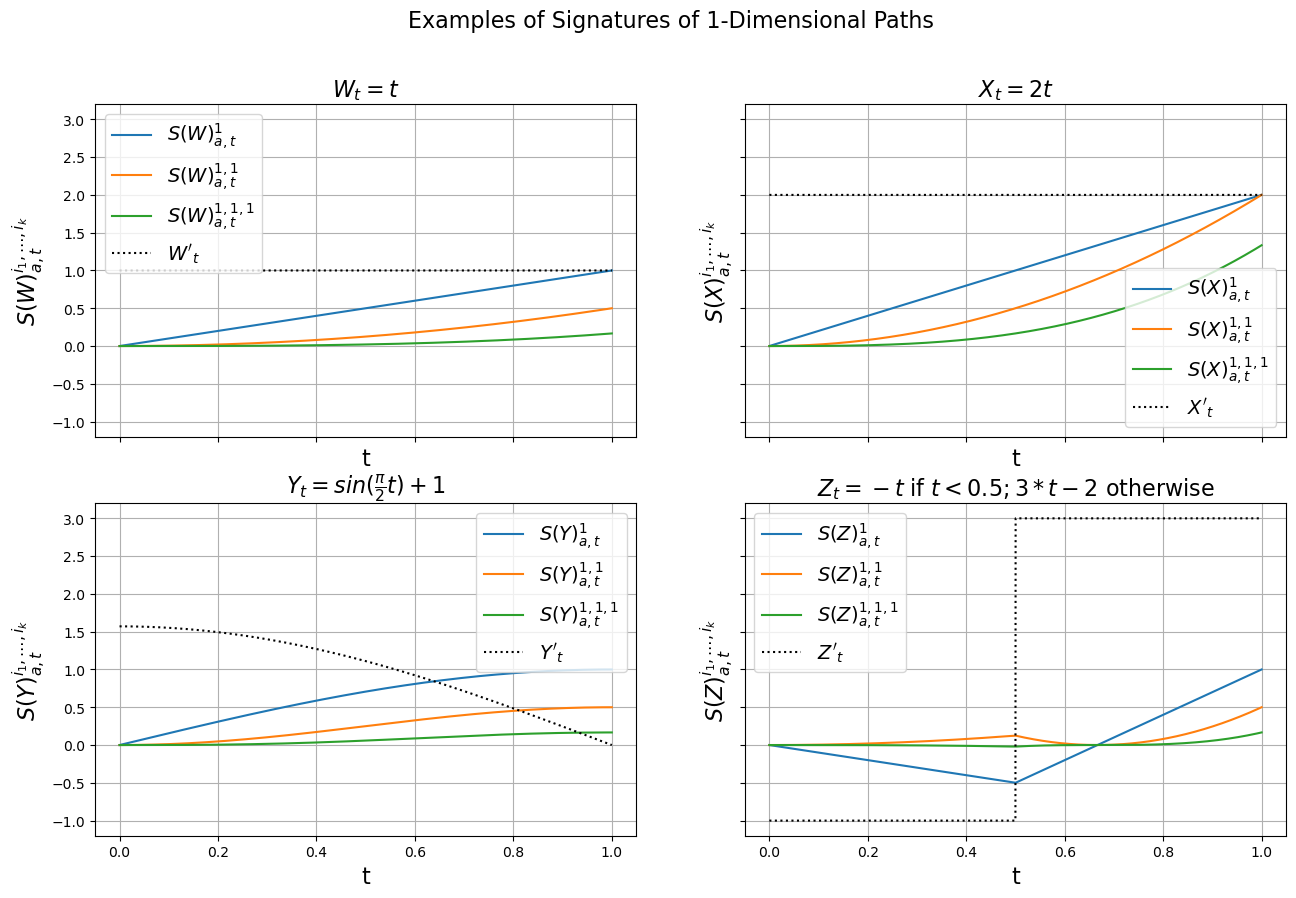

In [16]:
def compute_path_signature(X, a=0, b=1, level_threshold=3):
    N = len(X)
    t = np.linspace(a, b, 10**4)
    dt = t[1] - t[0]
    X_t = [Xi(t) for Xi in X]
    t = t[:-1]
    dX_t = [np.diff(Xi_t) for Xi_t in X_t]
    X_prime_t = [dXi_t / dt for dXi_t in dX_t]
    
    signature = [[np.ones(len(t))]]
    for k in range(level_threshold):
        previous_level = signature[-1]
        current_level = []
        for previous_level_integral in previous_level:
            for i in range(N):
                current_level.append(np.cumsum(previous_level_integral * dX_t[i]))
        signature.append(current_level)

    signature_terms = [list(itertools.product(*([np.arange(1, N+1).tolist()] * i)))
                       for i in range(0, level_threshold+1)]
    
    return t, X_t, X_prime_t, signature, signature_terms

def plot_path_signature(t, X_t, X_prime_t, signature, signature_terms, path_title, axs):
    path_symbol = path_title[1]
    
    # Flatten lists
    signature = [integral for level in signature for integral in level] 
    signature_terms = [term for level in signature_terms for term in level]
    
    for i, ax in enumerate(axs):
        n = i + 1
        signature_filtered, signature_terms_filtered = zip(*[(integral, term)
                                                             for integral, term in zip(signature, signature_terms)
                                                             if len(term) > 0 and term[-1] == n])
        for integral, term in zip(signature_filtered, signature_terms_filtered):
            ax.plot(t, integral, label='$S(' + path_symbol + ')_{a,t}^{' +','.join([str(v) for v in term]) + '}$')
        
        ax.plot(t, X_prime_t[i], color='black', linestyle=':', label="$" + path_symbol + "'_t$" if len(axs) == 1 else "$" + path_symbol + "'_t^{}$".format(n))
        
        if len(axs) == 1:
            ylabel = '$S(' + path_symbol + ')_{a,t}^{i_1, \ldots, i_k}$'
            title = path_title
        else:
            ylabel = '$S(' + path_symbol + ')_{a,t}^{i_1, \ldots, i_{k-1}, nnn}$'.replace('nnn', str(n))
            title = 'Signature terms ' + ylabel
        
        ax.set_title(title, fontsize=16)
        ax.set_xlabel('t', fontsize=16)
        ax.set_ylabel(ylabel, fontsize=16)
    
        ax.grid()
        ax.legend(fontsize=14)
        
paths = ((lambda t: t, '$W_t = t$'),
         (lambda t: 2 * t, '$X_t = 2t$'),
         (lambda t: np.sin(np.pi / 2 * t) + 1, '$Y_t = sin(\\frac{\\pi}{2} t) + 1$'),
         (lambda t: np.where(t < 0.5, -1 * t, 3 * t - 2), '$Z_t = -t $ if $ t < 0.5; 3 * t - 2$ otherwise'))

figure_height = 9.5
fig, axs = plt.subplots(2, 2, figsize=(figure_height * scipy.constants.golden_ratio, figure_height),
                        sharex=True, sharey=True)

for path, ax in zip(paths, axs.flatten()):
    t, X_t, X_prime_t, signature, signature_terms = compute_path_signature([path[0]])
    plot_path_signature(t, X_t, X_prime_t, signature, signature_terms, path[1], [ax])

plt.suptitle('Examples of Signatures of 1-Dimensional Paths', fontsize=16)
plt.show()

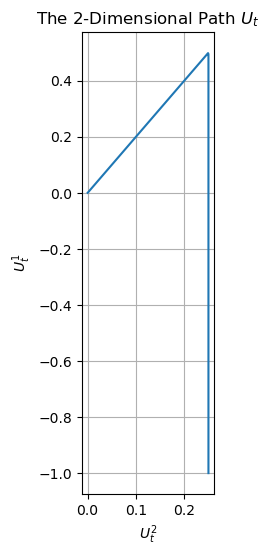

In [17]:
U = (((lambda t: np.where(t < 0.5, t, -3*t+2),
       lambda t: np.where(t < 0.5, 0.5*t, 0.25)), '$U_t'))

t = np.linspace(0, 1, 300)
U1_t = U[0][0](t)
U2_t = U[0][1](t)

figure_height = 6.0
plt.figure(figsize=(figure_height/3.5, figure_height))
plt.plot(U2_t, U1_t)
plt.xlabel('$U^2_t$')
plt.ylabel('$U^1_t$')
plt.title('The 2-Dimensional Path $U_t$')
plt.grid()
plt.show()

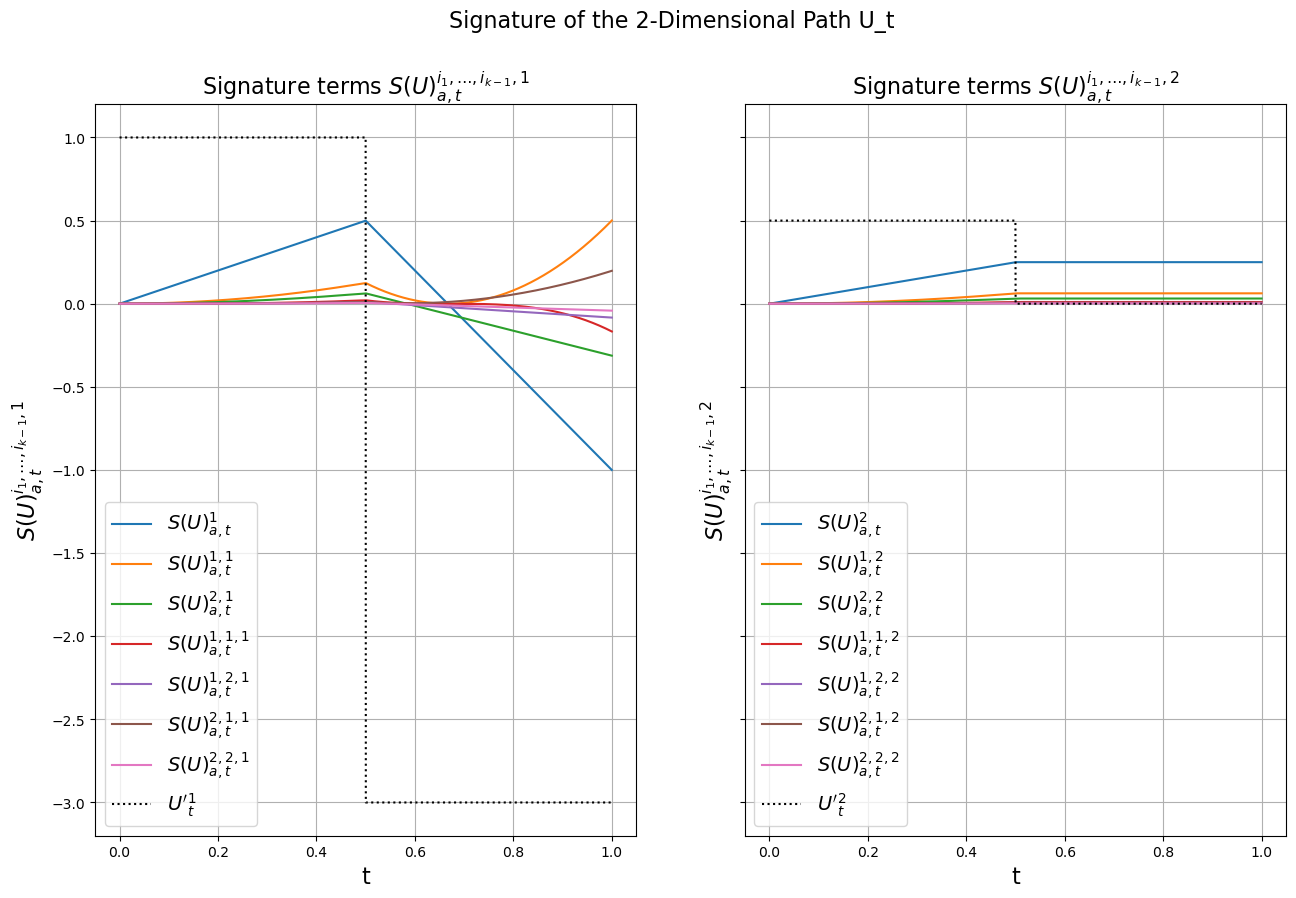

In [18]:
figure_height = 9.5
fig, axs = plt.subplots(1, 2, figsize=(figure_height * scipy.constants.golden_ratio, figure_height),
                        sharex=True, sharey=True)

t, U_t, U_prime_t, signature, signature_terms = compute_path_signature(U[0], a=0, b=1, level_threshold=3)
plot_path_signature(t, U_t, U_prime_t, signature, signature_terms, U[1], axs)

plt.suptitle('Signature of the 2-Dimensional Path U_t', fontsize=16)
plt.show()

In [19]:
print('Number of points in handwritten digit stream: {}'.format(len(df)))
print('Timestamp range: [{:.3f}, {:.3f}]'.format(min(df.index), max(df.index)))

Number of points in handwritten digit stream: 49
Timestamp range: [0.001, 1.201]


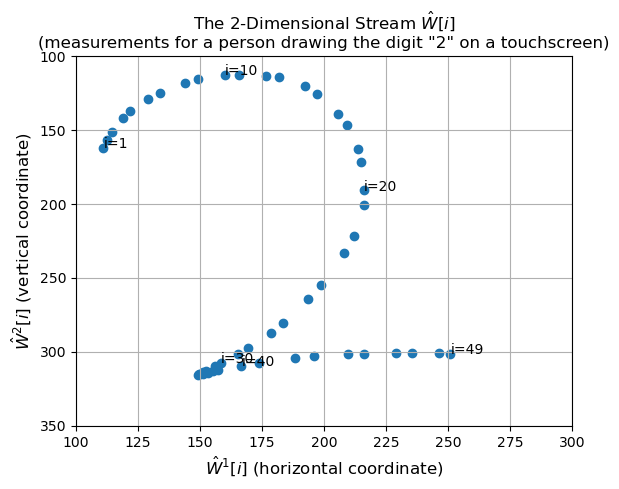

In [20]:
W1_i = df['ZX']
W2_i = df['ZY']
t_i = df.index
plt.scatter(W1_i, W2_i)
plt.xlim(100, 300)
plt.ylim(350, 100)

for i, (x, y) in enumerate(zip(W1_i, W2_i)):
    if i == 0 or i == len(W1_i) - 1 or (i+1) % 10 == 0:
        plt.text(x, y, 'i={}'.format(i+1))

plt.xlabel('$\hat{W}^1[i]$ (horizontal coordinate)', fontsize=12)
plt.ylabel('$\hat{W}^2[i]$ (vertical coordinate)', fontsize=12)
plt.title('The 2-Dimensional Stream $\hat W[i]$\n(measurements for a person drawing the digit "2" on a touchscreen)')
plt.grid()
plt.show()

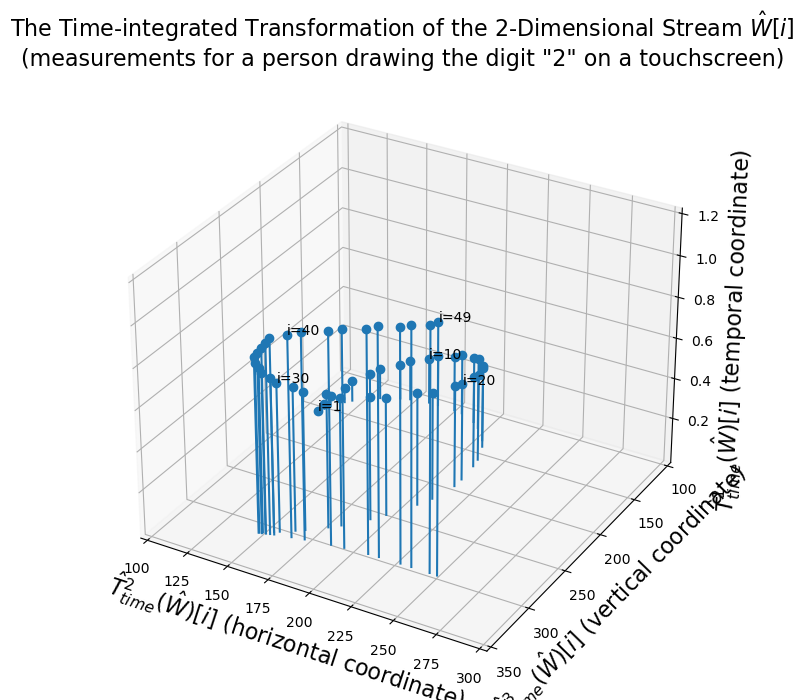

In [21]:
time_integrated_transformation = lambda t_i, W_i: np.vstack((t_i, W_i))

figure_height=8.0
fig = plt.figure(figsize=(figure_height * scipy.constants.golden_ratio, figure_height))
ax = fig.add_subplot(111, projection='3d')

def plot_stem3d(x, y, z, ax):
    for i, (xi, yi, zi) in enumerate(zip(x, y, z)):        
        line=art3d.Line3D(*zip((xi, yi, 0), (xi, yi, zi)), marker='o', markevery=(1, 1))
        ax.add_line(line)

        if i == 0 or i == len(x) - 1 or (i+1) % 10 == 0:
            ax.text(xi, yi, zi, 'i={}'.format(i+1))

W_i = np.array(df[['ZX', 'ZY']]).T
t_i = df.index

T_time = time_integrated_transformation(t_i, W_i)
plot_stem3d(x=T_time[1],
            y=T_time[2],
            z=T_time[0],
            ax=ax)

ax.set_xlabel('$\hat{T}^2_{time}(\hat{W})[i]$ (horizontal coordinate)', fontsize=16)
ax.set_ylabel('$\hat{T}^3_{time}(\hat{W})[i]$ (vertical coordinate)', fontsize=16)
ax.set_zlabel('$\hat{T}^1_{time}(\hat{W})[i]$ (temporal coordinate)', fontsize=16)
plt.title('The Time-integrated Transformation of the 2-Dimensional Stream $\hat W[i]$\n(measurements for a person drawing the digit "2" on a touchscreen)',
          fontsize=16)
ax.set_xlim3d(100, 300)
ax.set_ylim3d(350, 100)
ax.set_zlim3d(min(t_i), max(t_i))

plt.grid()
plt.show()

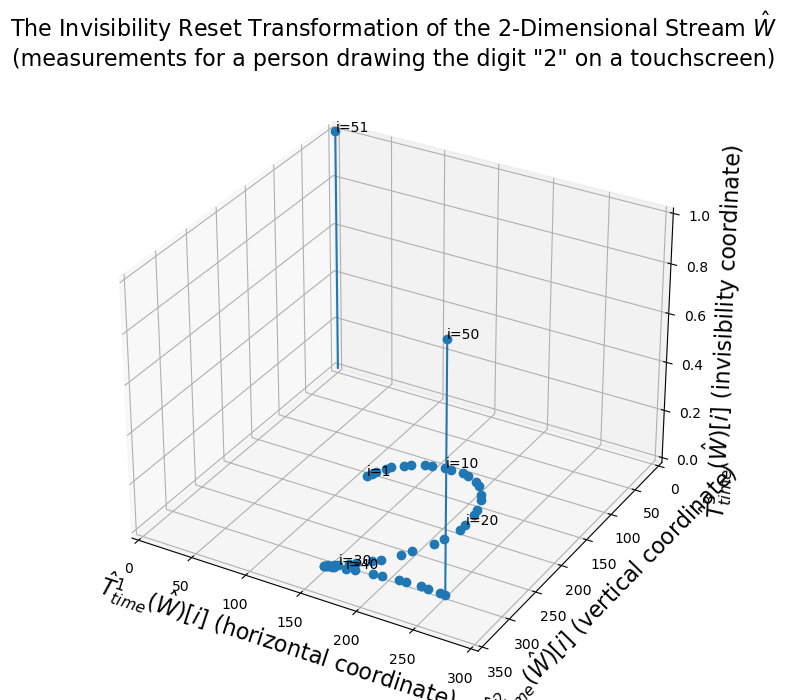

In [22]:
def invisibility_reset_transformation(W_i):
    W_i = np.hstack((W_i, W_i[:, -1:]))
    W_i = np.hstack((W_i, np.zeros((2, 1))))
    invisibility_indicator = np.zeros(W_i.shape[1])
    invisibility_indicator[-2:] = 1
    
    return np.vstack((W_i, invisibility_indicator))

figure_height=8.0
fig = plt.figure(figsize=(figure_height * scipy.constants.golden_ratio, figure_height))
ax = fig.add_subplot(111, projection='3d')

W_i = np.array(df[['ZX', 'ZY']]).T
t_i = df.index

T_time = invisibility_reset_transformation(W_i)
plot_stem3d(x=T_time[0],
            y=T_time[1],
            z=T_time[2],
            ax=ax)

ax.set_xlabel('$\hat{T}^1_{time}(\hat{W})[i]$ (horizontal coordinate)', fontsize=16)
ax.set_ylabel('$\hat{T}^2_{time}(\hat{W})[i]$ (vertical coordinate)', fontsize=16)
ax.set_zlabel('$\hat{T}^3_{time}(\hat{W})[i]$ (invisibility coordinate)', fontsize=16)
plt.title('The Invisibility Reset Transformation of the 2-Dimensional Stream $\hat W$\n(measurements for a person drawing the digit "2" on a touchscreen)',
          fontsize=16)
ax.set_xlim3d(0, 300)
ax.set_ylim3d(350, 0)
ax.set_zlim3d(0, 1)

plt.grid()
plt.show()

/var/folders/k3/vlz4x8zd4tng5d6mdsmrrknm0000gn/T/ipykernel_9644/2823489400.py:13: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  axs[0].stem(i, V_i, use_line_collection=True)


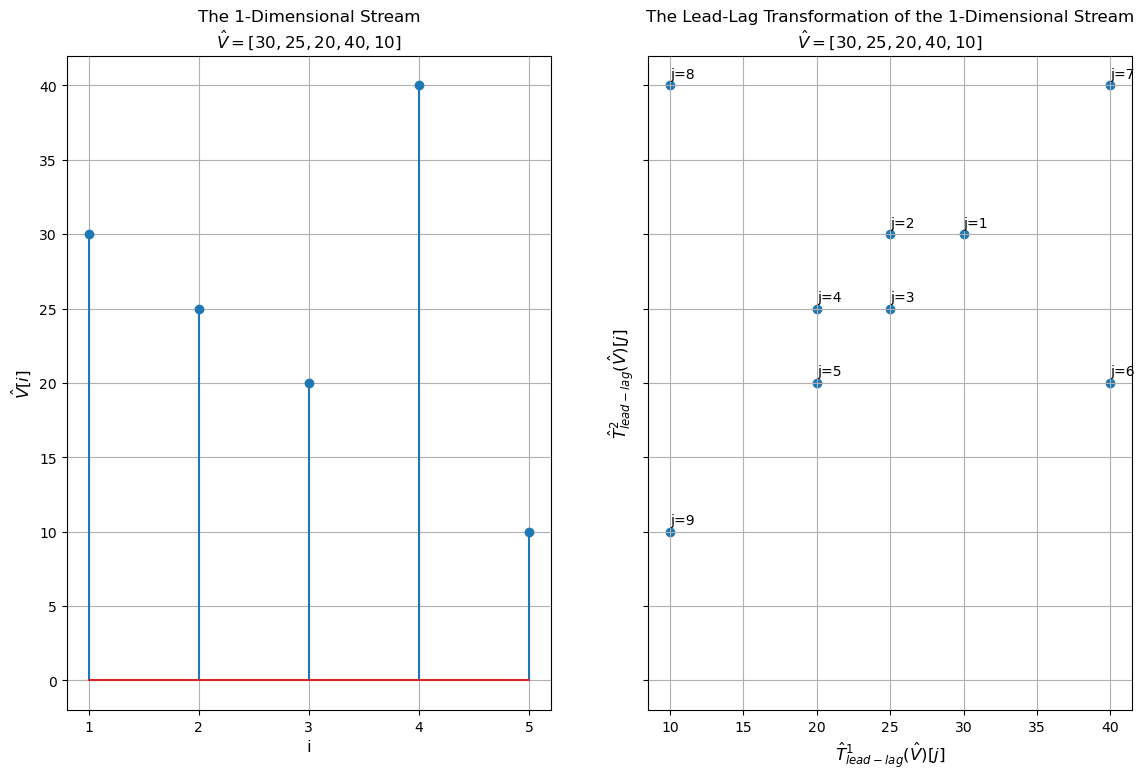

In [23]:
def lead_lag_transformation(V_i):
    V_i = np.repeat(V_i, 2)
    
    return np.vstack((V_i[1:], V_i[:-1]))

V_i = [30, 25, 20, 40, 10]
i = range(1, len(V_i) + 1)

figure_height = 8.5
fig, axs = plt.subplots(1, 2, figsize=(figure_height * scipy.constants.golden_ratio, figure_height),
                        sharex=False, sharey=True)

axs[0].stem(i, V_i, use_line_collection=True)
axs[0].set_xticks(i)
axs[0].set_xlabel('i', fontsize=12)
axs[0].set_ylabel('$\hat{V}[i]$', fontsize=12)
axs[0].set_title('The 1-Dimensional Stream\n$\hat V = {}$'.format(V_i))
axs[0].grid()

T_leadlag = lead_lag_transformation(V_i)
axs[1].scatter(T_leadlag[0], T_leadlag[1], alpha=1)
axs[1].set_xlabel('$\hat{T}^1_{lead-lag}(\hat{V})[j]$', fontsize=12)
axs[1].set_ylabel('$\hat{T}^2_{lead-lag}(\hat{V})[j]$', fontsize=12)
axs[1].set_title('The Lead-Lag Transformation of the 1-Dimensional Stream\n$\hat V = {}$'.format(V_i))
axs[1].grid()

for i, (xi, yi) in enumerate(zip(T_leadlag[0], T_leadlag[1])):
    axs[1].text(xi, yi+0.5, 'j={}'.format(i+1))
        
plt.show()

/var/folders/k3/vlz4x8zd4tng5d6mdsmrrknm0000gn/T/ipykernel_9644/2662548509.py:11: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  axs[0].stem(i, V_i, use_line_collection=True)
/var/folders/k3/vlz4x8zd4tng5d6mdsmrrknm0000gn/T/ipykernel_9644/2662548509.py:19: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  axs[1].stem(i, T_csum, use_line_collection=True)


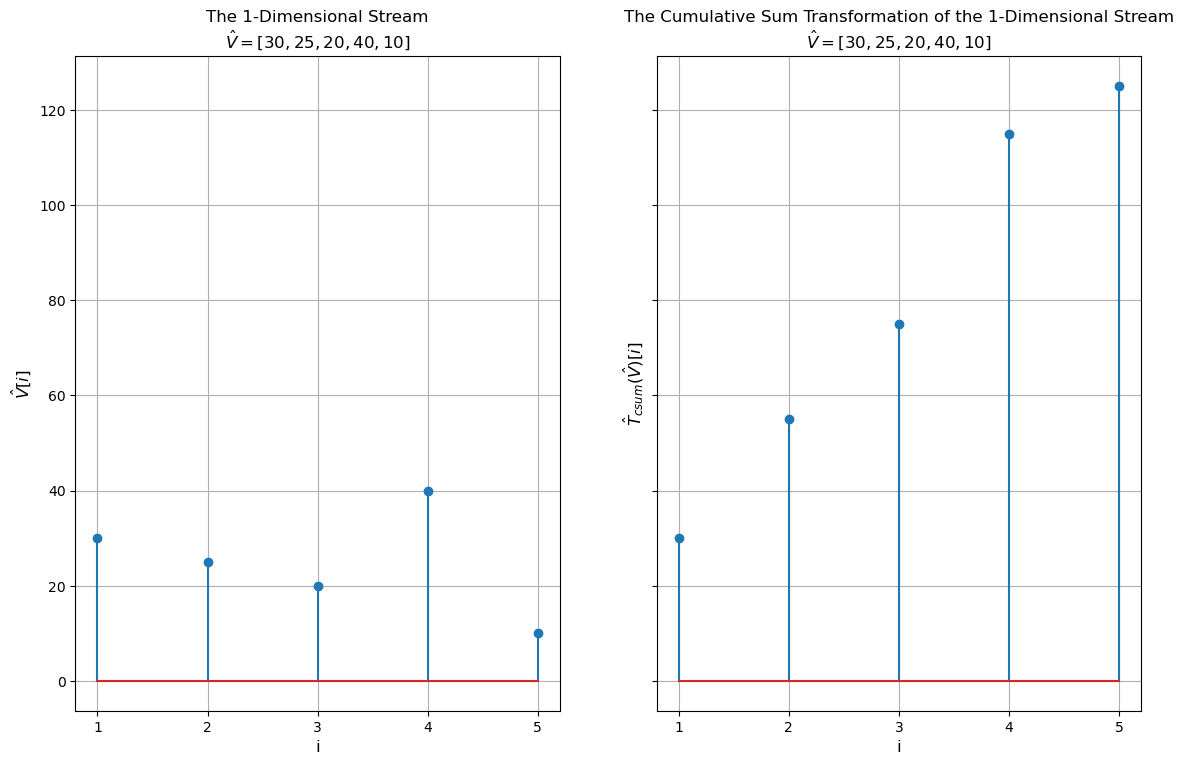

In [24]:
def cumulative_sum_transformation(V_i):    
    return np.cumsum(V_i)

V_i = [30, 25, 20, 40, 10]
i = range(1, len(V_i) + 1)

figure_height = 8.5
fig, axs = plt.subplots(1, 2, figsize=(figure_height * scipy.constants.golden_ratio, figure_height),
                        sharex=False, sharey=True)

axs[0].stem(i, V_i, use_line_collection=True)
axs[0].set_xticks(i)
axs[0].set_xlabel('i', fontsize=12)
axs[0].set_ylabel('$\hat{V}[i]$', fontsize=12)
axs[0].set_title('The 1-Dimensional Stream\n$\hat V = {}$'.format(V_i))
axs[0].grid()

T_csum = cumulative_sum_transformation(V_i)
axs[1].stem(i, T_csum, use_line_collection=True)
axs[1].set_xticks(i)
axs[1].set_xlabel('i', fontsize=12)
axs[1].set_ylabel('$\hat{T}_{csum}(\hat{V})[i]$', fontsize=12)
axs[1].set_title('The Cumulative Sum Transformation of the 1-Dimensional Stream\n$\hat V = {}$'.format(V_i))
axs[1].grid()
        
plt.show()

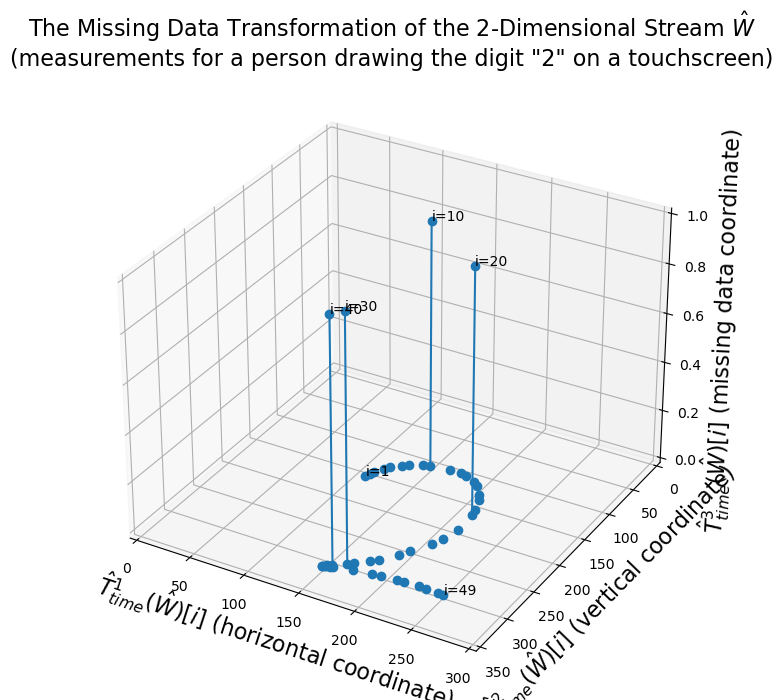

In [25]:
def missing_data_transformation(W_i):
    missing_value_indices = np.array(range(0, W_i.shape[1], 10)[1:], dtype=int) - 1
    # Mark every 10th point as missing
    W_i[:, missing_value_indices] = np.nan
    # Replace missing observations with their predecessors
    W_i[:, missing_value_indices] = W_i[:, missing_value_indices - 1]
    missing_value_mask = np.zeros(W_i.shape[1])
    missing_value_mask[missing_value_indices] = 1
    
    return np.vstack((W_i, missing_value_mask))

figure_height=8.0
fig = plt.figure(figsize=(figure_height * scipy.constants.golden_ratio, figure_height))
ax = fig.add_subplot(111, projection='3d')

W_i = np.array(df[['ZX', 'ZY']]).T
t_i = df.index

T_missing = missing_data_transformation(W_i)
plot_stem3d(x=T_missing[0],
            y=T_missing[1],
            z=T_missing[2],
            ax=ax)

ax.set_xlabel('$\hat{T}^1_{time}(\hat{W})[i]$ (horizontal coordinate)', fontsize=16)
ax.set_ylabel('$\hat{T}^2_{time}(\hat{W})[i]$ (vertical coordinate)', fontsize=16)
ax.set_zlabel('$\hat{T}^3_{time}(\hat{W})[i]$ (missing data coordinate)', fontsize=16)
plt.title('The Missing Data Transformation of the 2-Dimensional Stream $\hat W$\n(measurements for a person drawing the digit "2" on a touchscreen)',
          fontsize=16)
ax.set_xlim3d(0, 300)
ax.set_ylim3d(350, 0)
ax.set_zlim3d(0, 1)

plt.grid()
plt.show()